# Synaptic Routing Architecture (SRA) Quickstart

このノートブックは、SRAの基本的な仕組みと、その主要な特徴である「ルーティング」の挙動を簡単に体験するためのデモです。
Google Colabなどの環境で、上から順番にセルを実行するだけでSRAの動きを確認できます。

## 1. 環境のセットアップ
Google Colabで実行している場合は、以下のセルを実行してリポジトリをクローンし、必要なライブラリをインストールしてください。

In [1]:
# Colab環境でのみ実行してください（ローカル環境の場合はスキップ可）
import sys
if 'google.colab' in sys.modules:
    !git clone https://github.com/JunSuzukiJapan/SynapticRouter.git
    %cd SynapticRouter
    !pip install torch matplotlib seaborn

# パスの追加
sys.path.append('.')
sys.path.append('./src')
if 'google.colab' not in sys.modules:
    sys.path.append('..')
    sys.path.append('../src')


## 2. ライブラリのインポートとモデルの準備
SRAのMoE（Mixture of Experts）モデルを初期化します。

In [2]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from src.sra_gpu_models import MoESRAModel
class MoESRAConfig:
    def __init__(self, **kwargs):
        for k, v in kwargs.items():
            setattr(self, k, v)

# GPUが使える場合はGPUを使用
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 小さな設定でモデルを初期化
config = MoESRAConfig(
    vocab_size=100,
    d_model=64,
    n_layers=2,
    n_heads=4,
    num_synapses=4,  # 4つの専門家（シナプス）
    k=2,       # 各トークンにつき2つのシナプスを選択
    max_seq_len=64
)
model = MoESRAModel(config.vocab_size, config.d_model, config.n_layers, config.num_synapses, config.k, syn_hidden=128).to(device)
print("Model initialized!")

Using device: cpu
Model initialized!


## 3. ダミーデータでの順伝播とルーティングの確認
適当なデータを入力し、モデルがどのように各シナプス（専門家）へルーティングしているかを確認します。

In [3]:
# バッチサイズ2、シーケンス長10のダミーデータ
x = torch.randint(0, config.vocab_size, (2, 10)).to(device)

model.eval()
with torch.no_grad():
    y_in = torch.cat([torch.full((x.size(0), 1), 1, dtype=torch.long, device=device), x[:, :-1]], dim=1)
    outputs, routing_weights, _ = model(x, y_in)
    
print("Output shape:", outputs.shape)
print("Number of layers with routing info:", len(routing_weights))

Output shape: torch.Size([2, 10, 100])
Number of layers with routing info: 2


## 4. ルーティングの可視化
特定の層において、各入力トークンがどのシナプス（専門家）にルーティングされたかをヒートマップで可視化します。
※ここでは学習前のランダムな状態でのルーティングを表示しています。タスクに特化して学習を進めることで、このルーティングが偏り（専門化）を見せるようになります。

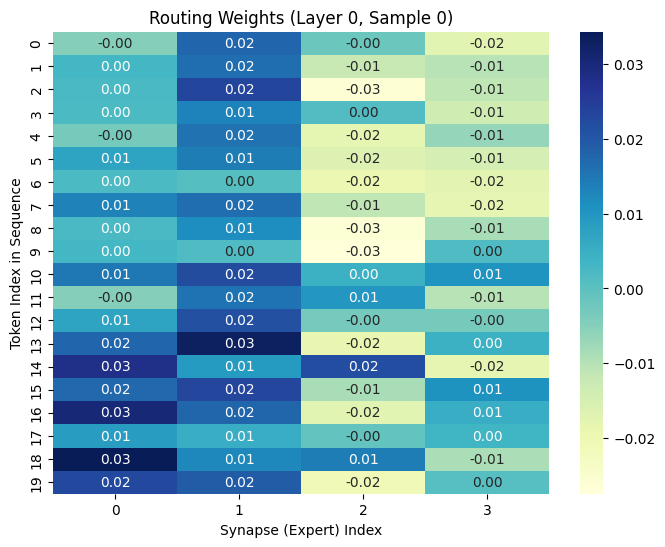

In [4]:
# 最初のサンプルの、最初のレイヤーのルーティング重みを取得
layer_idx = 0
sample_idx = 0
weights = routing_weights[layer_idx][sample_idx].cpu().numpy()

plt.figure(figsize=(8, 6))
sns.heatmap(weights, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title(f"Routing Weights (Layer {layer_idx}, Sample {sample_idx})")
plt.xlabel("Synapse (Expert) Index")
plt.ylabel("Token Index in Sequence")
plt.show()